In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [26]:
# Cambia este nombre si tu archivo CSV se llama de otra manera.
CSV_PATH = "backup_global_ph_graficos.csv"

In [27]:
df = pd.read_csv(
    CSV_PATH,
    sep=None,
    engine="python",
    usecols=["timestamp", "ph_F1", "ph_F2"],
    dtype={
        "timestamp": "string",
        "ph_F1": "string",
        "ph_F2": "string",
    },
)

In [28]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d-%m-%Y %H:%M",
    errors="raise",
)

def convertir_ph(serie):
    texto = serie.str.strip().replace("", pd.NA)
    entero_escalado = pd.to_numeric(
        texto.str.replace(".", "", regex=False),
        errors="coerce",
    )
    return entero_escalado.astype("float64") / 1_000_000

df["ph_F1"] = convertir_ph(df["ph_F1"])
df["ph_F2"] = convertir_ph(df["ph_F2"])

In [29]:
print(f"Total de registros: {len(df):,}")
print(f"Timestamp mínimo: {df['timestamp'].min()}")
print(f"Timestamp máximo: {df['timestamp'].max()}")
print(f"Valores válidos de ph_F1: {df['ph_F1'].notna().sum():,}")
print(f"Valores válidos de ph_F2: {df['ph_F2'].notna().sum():,}")

Total de registros: 122,354
Timestamp mínimo: 2026-07-06 14:42:00
Timestamp máximo: 2026-07-14 16:54:00
Valores válidos de ph_F1: 122,326
Valores válidos de ph_F2: 122,326


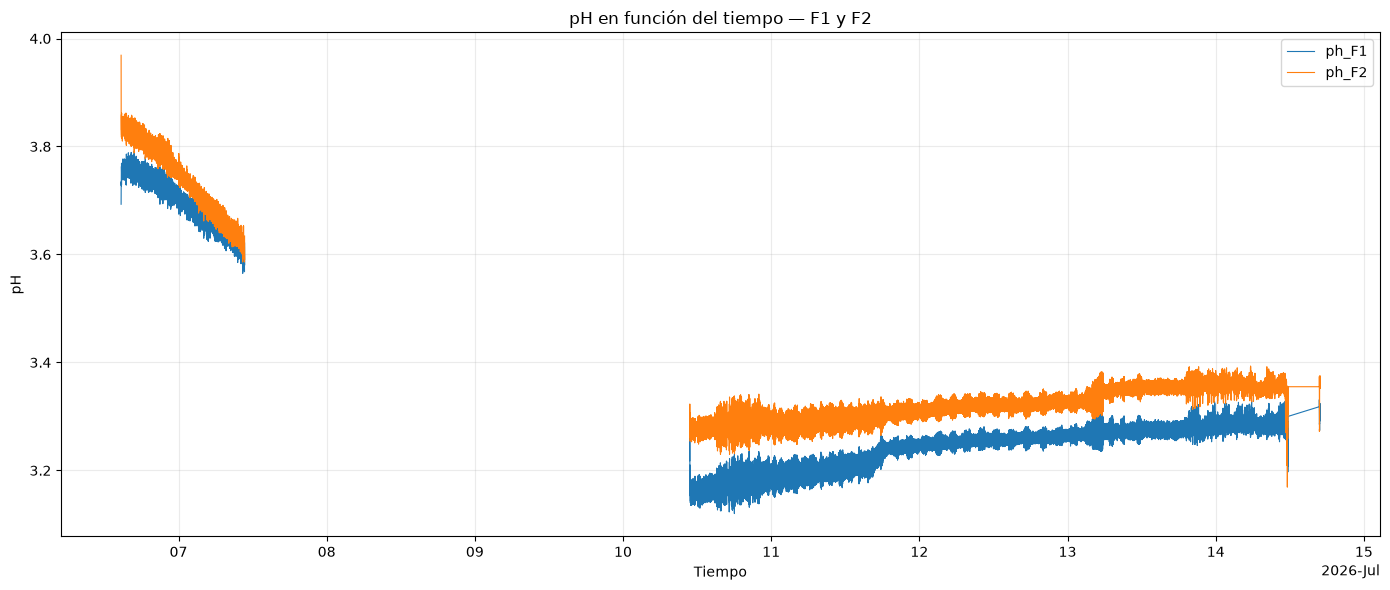

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["timestamp"], df["ph_F1"], linewidth=0.8, label="ph_F1")
ax.plot(df["timestamp"], df["ph_F2"], linewidth=0.8, label="ph_F2")
ax.set_title("pH en función del tiempo — F1 y F2")
ax.set_xlabel("Tiempo")
ax.set_ylabel("pH")
ax.legend()
ax.grid(True, alpha=0.25)
localizador = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
fig.tight_layout()
plt.show()

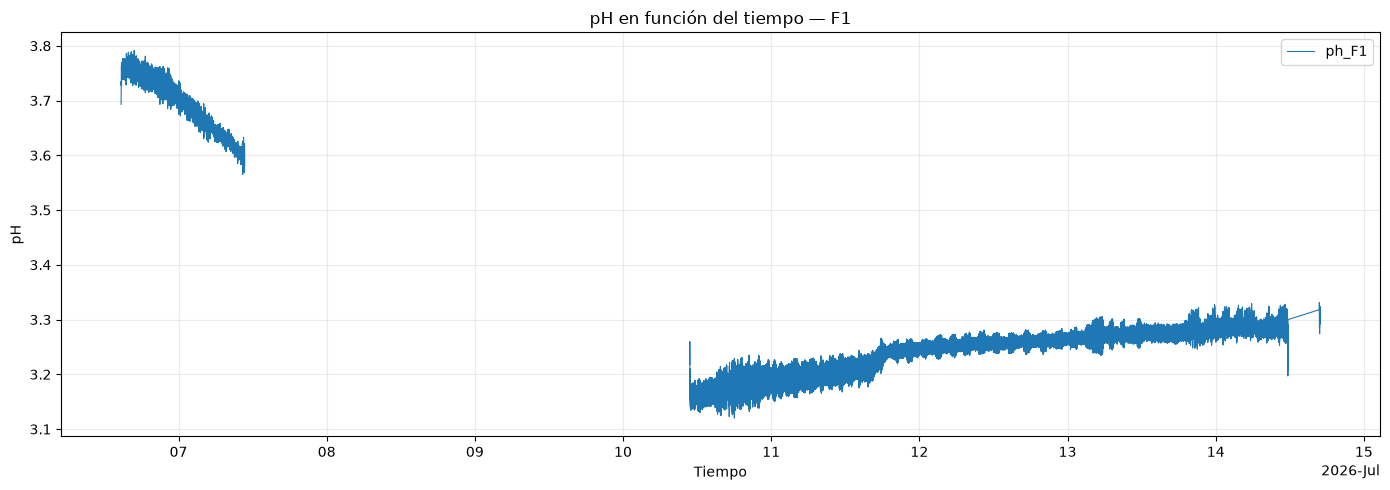

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["ph_F1"], color="tab:blue", linewidth=0.8, label="ph_F1")
ax.set_title("pH en función del tiempo — F1")
ax.set_xlabel("Tiempo")
ax.set_ylabel("pH")
ax.legend()
ax.grid(True, alpha=0.25)
localizador = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
fig.tight_layout()
plt.show()

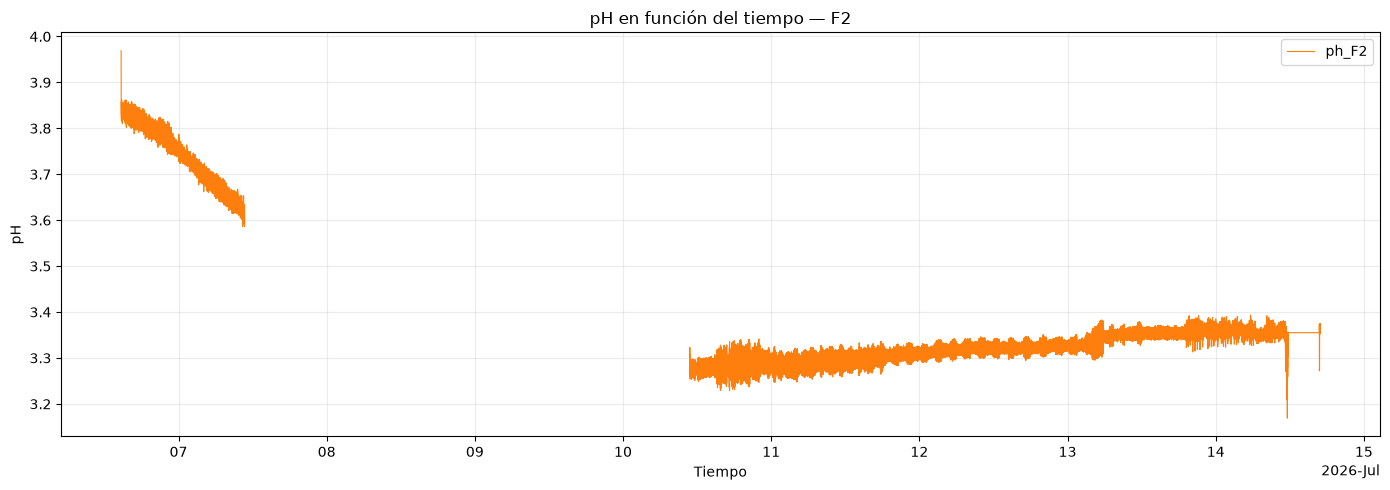

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["ph_F2"], color="tab:orange", linewidth=0.8, label="ph_F2")
ax.set_title("pH en función del tiempo — F2")
ax.set_xlabel("Tiempo")
ax.set_ylabel("pH")
ax.legend()
ax.grid(True, alpha=0.25)
localizador = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
fig.tight_layout()
plt.show()